In [21]:
import pandas as pd 
import matplotlib.pyplot as plt
df = pd.read_csv('Stock Prices Data Set.csv', parse_dates=['date'], index_col = ('date'))
from statsmodels.tsa.seasonal import seasonal_decompose
df.head(5)

,symbol,open,high,low,close,volume
date,,,,,,
2014-01-02,AAL,25.0700,25.8200,25.0600,25.3600,8998943
2014-01-02,AAPL,79.3828,79.5756,78.8601,79.0185,58791957
2014-01-02,AAP,110.3600,111.8800,109.2900,109.7400,542711
2014-01-02,ABBV,52.1200,52.3300,51.5200,51.9800,4569061
2014-01-02,ABC,70.1100,70.2300,69.4800,69.8900,1148391


In [7]:
type(df.date[0])

pandas._libs.tslibs.timestamps.Timestamp

In [10]:
df.index

DatetimeIndex(['2014-01-02', '2014-01-02', '2014-01-02', '2014-01-02',
               '2014-01-02', '2014-01-02', '2014-01-02', '2014-01-02',
               '2014-01-02', '2014-01-02',
               ...
               '2017-12-29', '2017-12-29', '2017-12-29', '2017-12-29',
               '2017-12-29', '2017-12-29', '2017-12-29', '2017-12-29',
               '2017-12-29', '2017-12-29'],
              dtype='datetime64[ns]', name='date', length=497472, freq=None)

In [15]:
mask = (df.index.year == 2017) & (df.index.month == 12)
print(df[mask])

           symbol    open    high       low   close    volume
date                                                         
2017-12-01    AAL   49.67   50.38   48.6900   49.00   6229631
2017-12-01   AAPL  169.95  171.67  168.5000  171.05  39759288
2017-12-01    AAP  100.74  100.97   97.8900   99.28   2253440
2017-12-01   ABBV   97.19   98.52   94.3000   96.32   4823240
2017-12-01    ABC   83.98   85.25   81.2076   84.95   3188555
...           ...     ...     ...       ...     ...       ...
2017-12-29    XYL   68.53   68.80   67.9200   68.20   1046677
2017-12-29    YUM   82.64   82.71   81.5900   81.61   1347613
2017-12-29    ZBH  121.75  121.95  120.6200  120.67   1023624
2017-12-29   ZION   51.28   51.55   50.8100   50.83   1261916
2017-12-29    ZTS   72.55   72.76   72.0400   72.04   1704122

[10098 rows x 6 columns]


In [16]:
df.isnull().sum()

symbol     0
open      11
high       8
low        8
close      0
volume     0
dtype: int64

In [17]:
df['open'] = df['open'].ffill()
df['high'] = df['high'].ffill()
df['low']  = df['low'].ffill()

In [19]:
df_aapl = df[df['symbol'] == 'AAPL']['close'].copy()
df_aapl = df_aapl.resample('M').mean()
print(df_aapl.head())
print("Shape:", df_aapl.shape)

date
2014-01-31    76.777876
2014-02-28    75.225637
2014-03-31    76.173400
2014-04-30    77.296243
2014-05-31    86.170752
Freq: ME, Name: close, dtype: float64
Shape: (48,)


C:\Users\HomePC\AppData\Local\Temp\ipykernel_19452\4023942718.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_aapl = df_aapl.resample('M').mean()


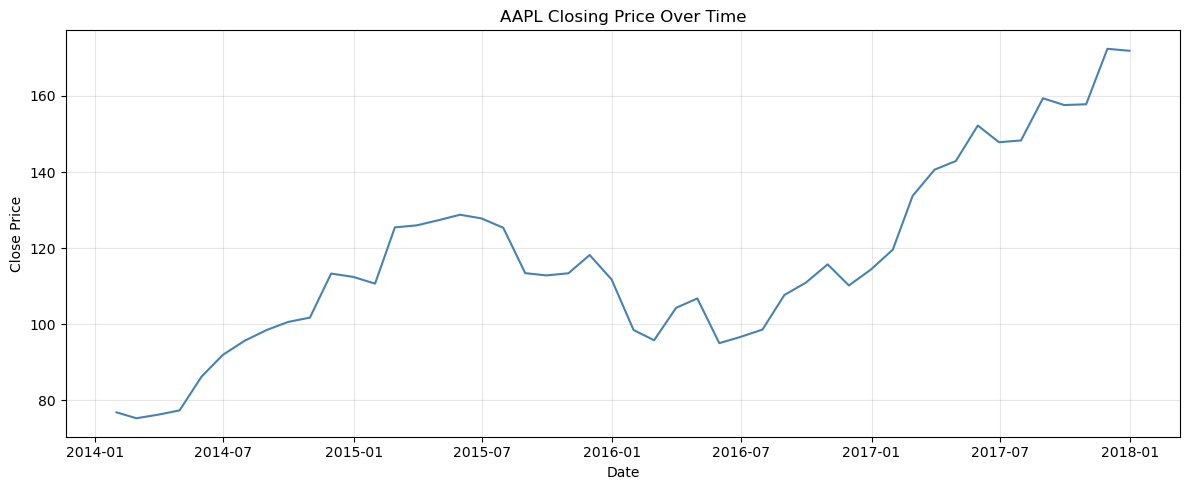

In [22]:
plt.figure(figsize=(12, 5))
plt.plot(df_aapl, color='steelblue', linewidth=1.5)
plt.title('AAPL Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

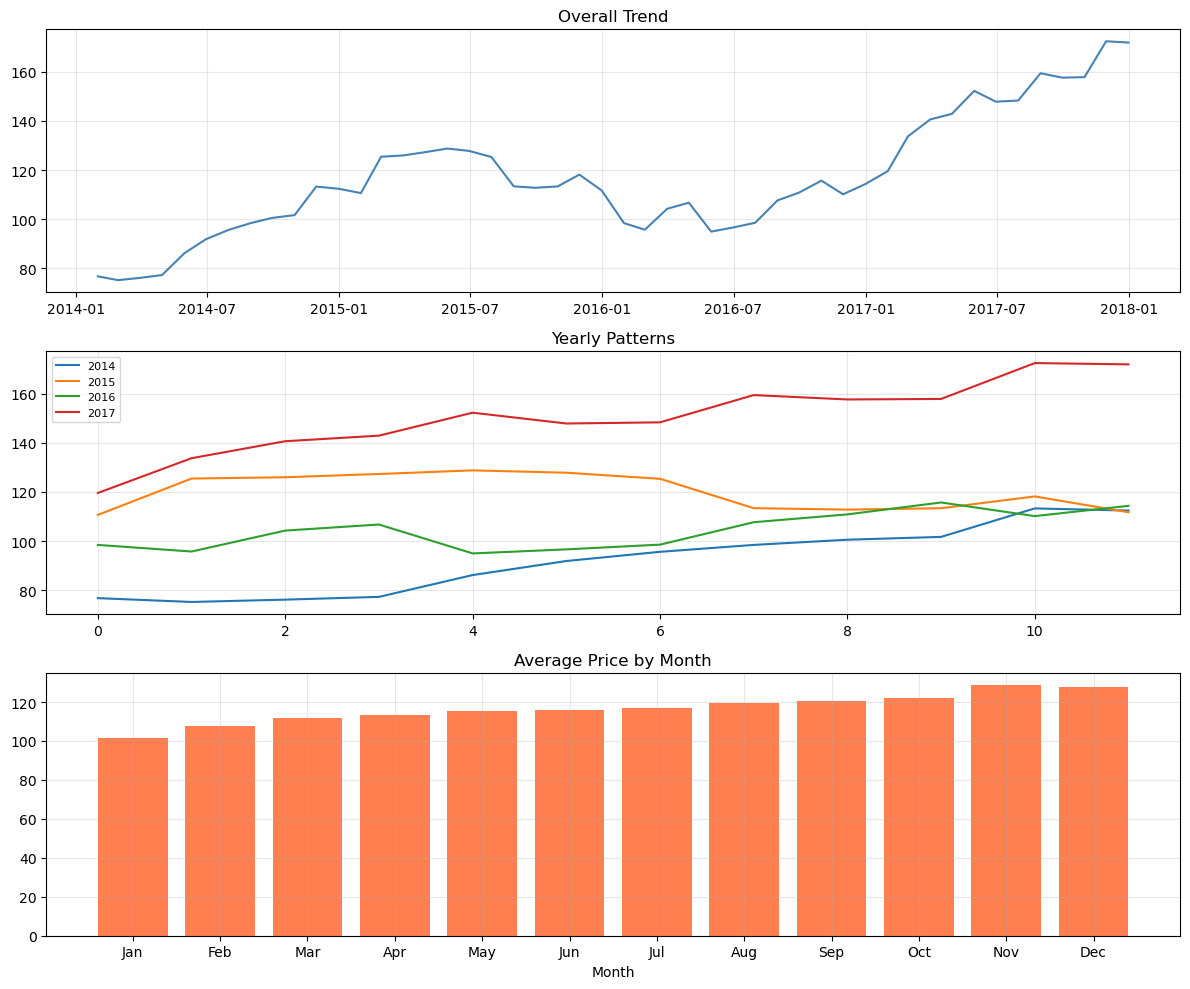

In [23]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10))


axes[0].plot(df_aapl, color='steelblue')
axes[0].set_title('Overall Trend')
axes[0].grid(True, alpha=0.3)


for year in df_aapl.index.year.unique():
    yearly = df_aapl[df_aapl.index.year == year]
    axes[1].plot(yearly.values, label=str(year))
axes[1].set_title('Yearly Patterns')
axes[1].legend(loc='upper left', fontsize=8)
axes[1].grid(True, alpha=0.3)


monthly_avg = df_aapl.groupby(df_aapl.index.month).mean()
axes[2].bar(monthly_avg.index, monthly_avg.values, color='coral')
axes[2].set_title('Average Price by Month')
axes[2].set_xlabel('Month')
axes[2].set_xticks(range(1, 13))
axes[2].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                          'Jul','Aug','Sep','Oct','Nov','Dec'])
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


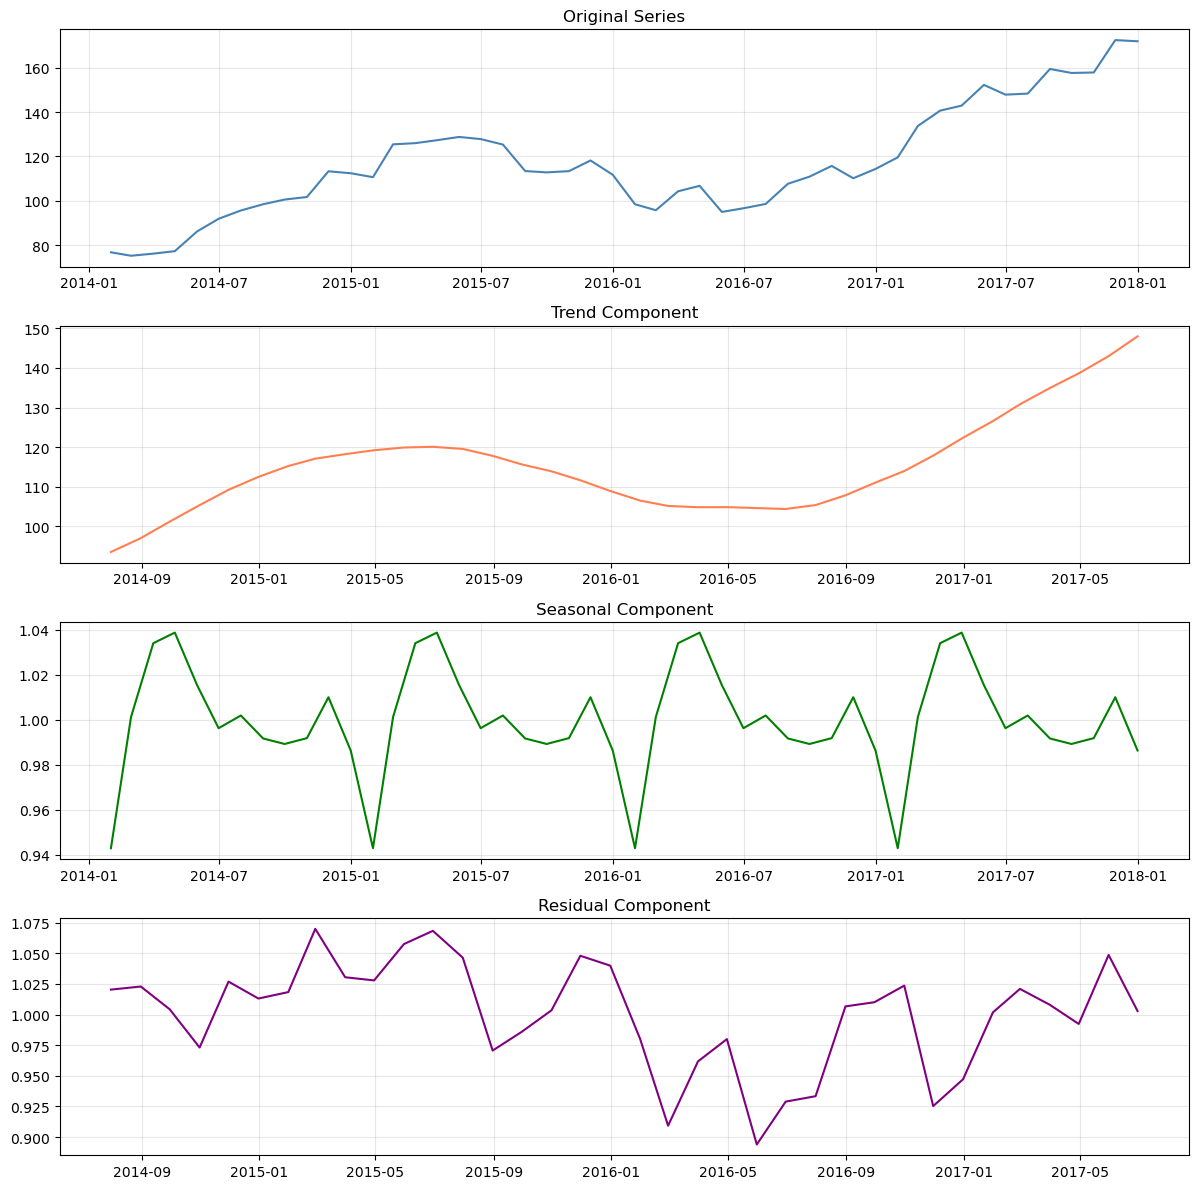

In [24]:

decomposition = seasonal_decompose(
    df_aapl,
    model='multiplicative',  
    period=12                
)


fig, axes = plt.subplots(4, 1, figsize=(12, 12))


axes[0].plot(decomposition.observed, color='steelblue')
axes[0].set_title('Original Series')
axes[0].grid(True, alpha=0.3)


axes[1].plot(decomposition.trend, color='coral')
axes[1].set_title('Trend Component')
axes[1].grid(True, alpha=0.3)


axes[2].plot(decomposition.seasonal, color='green')
axes[2].set_title('Seasonal Component')
axes[2].grid(True, alpha=0.3)


axes[3].plot(decomposition.resid, color='purple')
axes[3].set_title('Residual Component')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [26]:

trend      = decomposition.trend
seasonal   = decomposition.seasonal
residual   = decomposition.resid


print("Trend:\n",    trend.describe())
print("\nSeasonal:\n", seasonal.describe())
print("\nResidual:\n", residual.describe())


Trend:
 count     36.000000
mean     115.186876
std       12.295104
min       93.538950
25%      105.380745
50%      113.932937
75%      119.638446
max      147.957115
Name: trend, dtype: float64

Seasonal:
 count    48.000000
mean      1.000000
std       0.023908
min       0.942923
25%       0.991108
50%       0.998780
75%       1.011400
max       1.038778
Name: seasonal, dtype: float64

Residual:
 count    36.000000
mean      1.000036
std       0.043998
min       0.894004
25%       0.978239
50%       1.007286
75%       1.027096
max       1.069870
Name: resid, dtype: float64


In [27]:

df_aapl_ma = pd.DataFrame({'Original': df_aapl})

df_aapl_ma['MA_3']  = df_aapl.rolling(window=3).mean()   
df_aapl_ma['MA_6']  = df_aapl.rolling(window=6).mean()   
df_aapl_ma['MA_12'] = df_aapl.rolling(window=12).mean() 

print(df_aapl_ma.head(15))

              Original        MA_3        MA_6       MA_12
date                                                      
2014-01-31   76.777876         NaN         NaN         NaN
2014-02-28   75.225637         NaN         NaN         NaN
2014-03-31   76.173400   76.058971         NaN         NaN
2014-04-30   77.296243   76.231760         NaN         NaN
2014-05-31   86.170752   79.880132         NaN         NaN
2014-06-30   91.885429   85.117475   80.588223         NaN
2014-07-31   95.625586   91.227256   83.729508         NaN
2014-08-31   98.436619   95.315878   87.598005         NaN
2014-09-30  100.548571   98.203592   91.660533         NaN
2014-10-31  101.699565  100.228252   95.727754         NaN
2014-11-30  113.285000  105.177712  100.246795         NaN
2014-12-31  112.410909  109.131825  103.667709   92.127966
2015-01-31  110.641500  112.112470  106.170361   94.949934
2015-02-28  125.431316  116.161242  110.669477   99.133741
2015-03-31  125.970682  120.681166  114.906495  103.2835

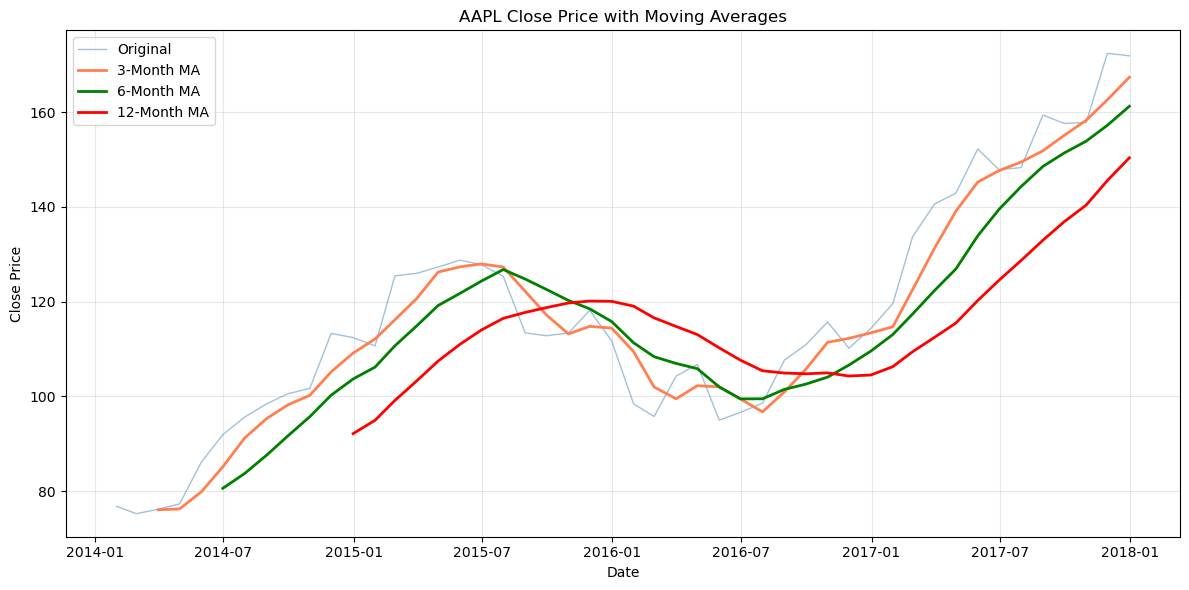

In [28]:
plt.figure(figsize=(12, 6))

plt.plot(df_aapl_ma['Original'], 
         color='steelblue', alpha=0.5, linewidth=1, label='Original')
plt.plot(df_aapl_ma['MA_3'],  
         color='coral',  linewidth=2, label='3-Month MA')
plt.plot(df_aapl_ma['MA_6'],  
         color='green',  linewidth=2, label='6-Month MA')
plt.plot(df_aapl_ma['MA_12'], 
         color='red',    linewidth=2, label='12-Month MA')

plt.title('AAPL Close Price with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()